### 1. Basic Statistics

In [11]:
import numpy as np

# Given Dataset (Daily Customer Arrivals for 20 days)
daily_arrivals = np.array([8, 12, 10, 15, 9, 13, 11, 14, 7, 16, 10, 12, 9, 15, 11, 13, 14, 8, 12, 10])

# Task 1: Basic Statistics
mean_val = np.mean(daily_arrivals)
pop_variance = np.var(daily_arrivals)  # Population variance (ddof=0 by default)
std_deviation = np.std(daily_arrivals)
sample_variance = np.var(daily_arrivals, ddof=1) # Sample variance
pop_sample_diff = abs(pop_variance - sample_variance)

print(f"Mean: {mean_val}")
print(f"Population Variance: {pop_variance:.2f}")
print(f"Standard Deviation: {std_deviation:.2f}")
print(f"Sample Variance: {sample_variance:.2f}")

print("\nDifference:")
print(f"The difference between Population Variance and Sample Variance is {pop_sample_diff:.2f}")
print("Population Variance: It is used when we have data for the entire group (all 20 days are the whole population).")
print("Sample Variance: It is used when the data is a small subset of a larger group; it uses (n-1) to be more conservative and account for potential bias.")

Mean: 11.45
Population Variance: 6.35
Standard Deviation: 2.52
Sample Variance: 6.68

Difference:
The difference between Population Variance and Sample Variance is 0.33
Population Variance: It is used when we have data for the entire group (all 20 days are the whole population).
Sample Variance: It is used when the data is a small subset of a larger group; it uses (n-1) to be more conservative and account for potential bias.


### 2. Random Number Generation

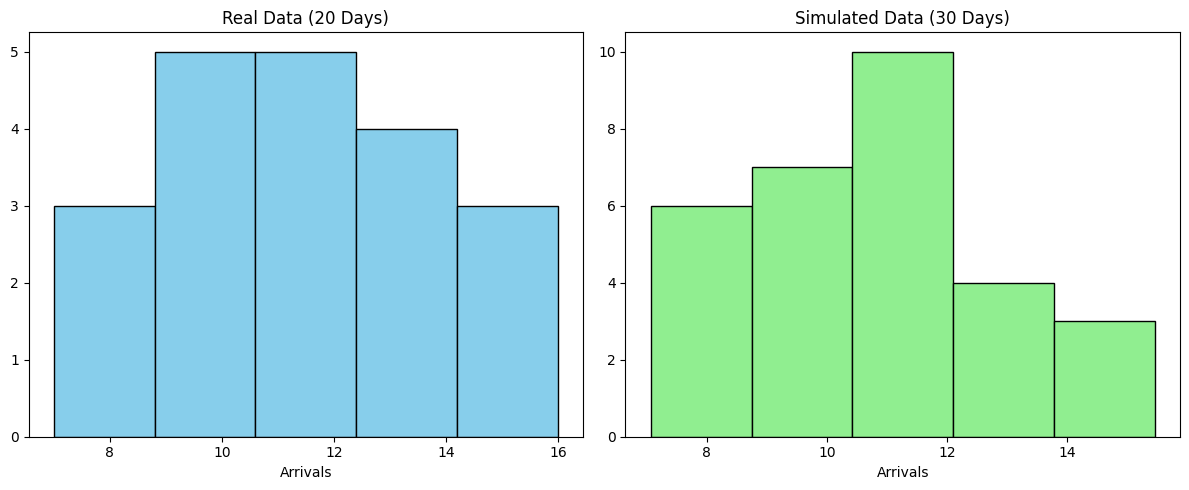

In [12]:
import matplotlib.pyplot as plt

# Task 2: Random Number Generation (Uniform Distribution)
min_val = np.min(daily_arrivals)
max_val = np.max(daily_arrivals)

# Generate simulated data for 30 days
simulated_data = np.random.uniform(min_val, max_val, 30)

# Plotting
plt.figure(figsize=(12, 5))

# Histogram of real data
plt.subplot(1, 2, 1)
plt.hist(daily_arrivals, bins=5, color='skyblue', edgecolor='black')
plt.title('Real Data (20 Days)')
plt.xlabel('Arrivals')

# Histogram of simulated data
plt.subplot(1, 2, 2)
plt.hist(simulated_data, bins=5, color='lightgreen', edgecolor='black')
plt.title('Simulated Data (30 Days)')
plt.xlabel('Arrivals')

plt.tight_layout()
plt.show()

### 3. Monte Carlo Simulation

In [13]:
# Task 3: Monte Carlo Simulation
# Generating 100,000 random samples using the uniform distribution bounds from Task 2
mc_samples = np.random.uniform(min_val, max_val, 100000)

# Estimate probability that arrivals are greater than 15
probability_gt_15 = np.mean(mc_samples > 15)


print(f"Estimated Probability (Arrivals > 15): {probability_gt_15:.4f}")

Estimated Probability (Arrivals > 15): 0.1124


### 4. Hypothesis Testing

Hypothesized Mean: 13
t-statistic: -2.6817
p-value: 0.0148


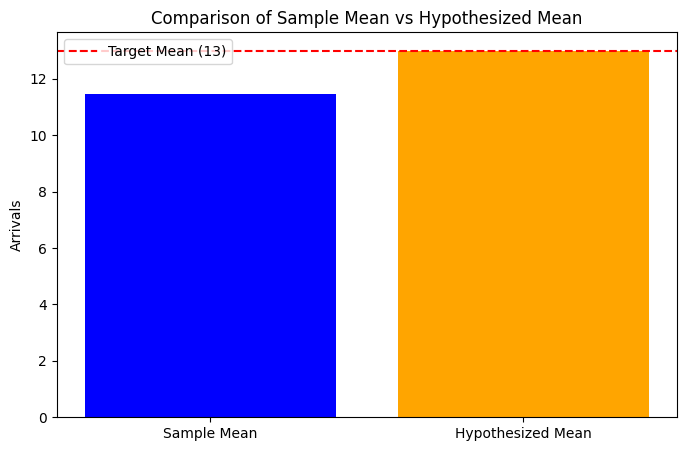


Conclusion:
Reject the Null Hypothesis (H0).
There is a significant difference between the observed mean and the hypothesized mean of 13.


In [14]:
from scipy import stats

# Task 4: Hypothesis Testing
# Hypothesized Mean
# (033 mod 10) + 10 = 3 + 10 = 13
hypothesized_mean = 13

# One-Sample t-test
t_stat, p_value = stats.ttest_1samp(daily_arrivals, hypothesized_mean)

print(f"Hypothesized Mean: {hypothesized_mean}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(['Sample Mean', 'Hypothesized Mean'], [mean_val, hypothesized_mean], color=['blue', 'orange'])
plt.axhline(y=hypothesized_mean, color='red', linestyle='--', label='Target Mean (13)')
plt.title('Comparison of Sample Mean vs Hypothesized Mean')
plt.ylabel('Arrivals')
plt.legend()
plt.show()

# Conclusion
alpha = 0.05
print("\nConclusion:")
if p_value < alpha:
    print(f"Reject the Null Hypothesis (H0).")
    print("There is a significant difference between the observed mean and the hypothesized mean of 13.")
else:
    print(f"Fail to reject the Null Hypothesis (H0).")
    print("There is no significant evidence to suggest the mean daily arrivals are different from 13.")

### Interpretation of Result

In this simulation, we tested the observed mean of **11.45** arrivals against a hypothesized 'target' or 'expected' mean of **13**. The p-value of **0.0148** gave us a statistically significant reason to reject the idea that our store is averaging 13 customers a day.

**Operational Context:**
*   **Resource Gap:** If management has been scheduling staff or ordering inventory based on an expectation of 13 daily arrivals, the store is likely **over-staffed**. We are seeing roughly 12% fewer customers than the '033-derived' benchmark (13 vs 11.45).
*   **Efficiency vs. Service:** While a lower-than-expected arrival rate might mean lower stress for staff, it indicates a potential under-utilization of capital.
*   **Strategic Action:** This statistical mismatch suggests that the store should either adjust its operational baseline down to 11.5 to save on costs, or investigate why the actual traffic is significantly trailing behind the hypothesized target of 13.